In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from numba import njit

In [2]:
L = 10
temp = np.linspace(2.269, 5, 10)
temp = [temp[0], temp[-7], temp[-3], temp[-1]]

In [3]:
temp

[2.269, 3.179333333333333, 4.393111111111111, 5.0]

In [4]:
all_states = []
all_energies = []
all_magnetizations = []

a, b = 18200, 18950
for T in temp:
    loaded_energy = np.load(os.path.join("Data2", f"L_{L}", f"T_{T}", "energy.npy"))
    loaded_magnetization = np.load(os.path.join("Data2", f"L_{L}", f"T_{T}", "magnitization.npy"))
    loaded_states = np.load(os.path.join("Data2", f"L_{L}", f"T_{T}", "states.npy"))
    if T == temp[0]:
        all_states.append(loaded_states[a:b])
        all_energies.append(loaded_energy[a:b])
        all_magnetizations.append(loaded_magnetization[a:b])
    else:
        all_states.append(loaded_states[15000:25000])
        all_energies.append(loaded_energy[15000:25000])
        all_magnetizations.append(loaded_magnetization[15000:25000])

In [5]:
def remove_identical_states(states):
    unique_hashes = set()
    unique_states = []

    for state in states:
        state_hash = hash(state.tobytes())
        if state_hash not in unique_hashes:
            unique_hashes.add(state_hash)
            unique_states.append(state)

    return np.array(unique_states)

unique_states = remove_identical_states(all_states[0])
len(unique_states), len(all_states[0])

(750, 750)

In [6]:
@njit
def hamming_distances(states):
    #Calculating the hamming distances between the states
    #here, we again make sure that no 2 states are same
    num_states, L, _ = states.shape
    distances = np.zeros((num_states, num_states - 1))
    for i in range(num_states):
        ref_state = states[i]
        index = 0
        for j in range(num_states):
            if i != j:
                diff = np.abs(ref_state - states[j])
                distances[i, index] = np.sum(diff)
                index += 1
    return distances

In [18]:
dist1 = hamming_distances(all_states[0])
dist2 = hamming_distances(all_states[1])
dist3 = hamming_distances(all_states[2])
dist4 = hamming_distances(all_states[3])

In [21]:
dist1 = hamming_distances(all_states[0])

In [23]:
nice = 2

Saved: Data2/L_10/Hamming_Distances\hamming_dist_T_2.269.npy


In [ ]:
final_distances = [dist1, dist2, dist3, dist4]
output_dir = "Data2/L_10/Hamming_Distances"
os.makedirs(output_dir, exist_ok=True)

for array, T in zip(final_distances, temp):
    filename = f"hamming_dist_T_{T}.npy"
    filepath = os.path.join(output_dir, filename)
    np.save(filepath, array)
    print(f"Saved: {filepath}")

In [24]:
loaded_distances = []
for T in temp:
    filepath = os.path.join(output_dir, f"hamming_dist_T_{T}.npy")
    array = np.load(filepath)
    loaded_distances.append(array)

In [25]:
def min_dist(dist):
    new_dist = []
    min_index = []
    for i in range(len(dist)):
        new_dist.append(np.min(dist[i]))
        min_index.append(np.argmin(dist[i]))
    return np.array(new_dist) , np.array(min_index)

In [26]:
new_distances = []
new_indices = []
for dist in loaded_distances:
    new_dist, new_index = min_dist(dist)
    new_distances.append(new_dist)
    new_indices.append(new_index)

for i in range(len(temp)):
    np.savetxt(f"Data2/L_10/Hamming_Distances/new_distances_T_{temp[i]}.txt", new_distances[i])

In [13]:
new_dist = []
for i in range(len(temp)):
    new_dist.append(np.loadtxt(f"Data2/L_10/Hamming_Distances/new_distances_T_{temp[i]}.txt"))

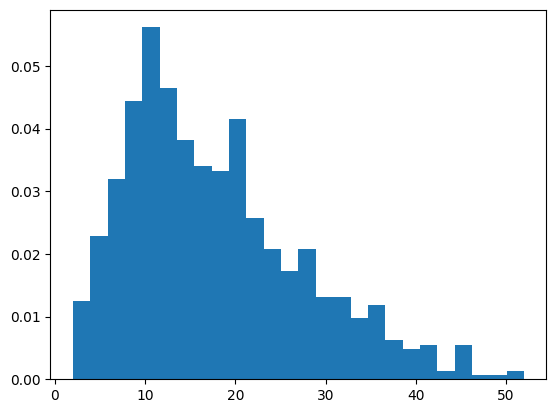

In [35]:
plt.hist(new_distances[0], bins=26, density = True)
plt.show()
plt.hist(new_distances[1], bins=22, density = True)
plt.show()
plt.hist(new_distances[2], bins=18, density = True)
plt.show()
plt.hist(new_distances[3], bins=18, density = True)
plt.show()